In [29]:
import sys
import uproot as ur

path_full = "/home/albert/Baikal2025/data_manager/data/exp_reco_root/exp_reco_files/2020_cl2_run6_scl_nu_DATA2020.root"
path_blind = "/home/albert/Baikal2025/data_manager/data/exp_reco_root/reco_blind_files/murecAnalysis_blind_2020_cl2_run6_scl_nu_DATA2020.root"

In [30]:
with ur.open(path_blind) as rf:
    group = rf['trAnalysis']
    print(group.keys())
    events_ids = group['fEvent'].array(library="np")
    thetas = group['fThetaRec'].array(library="np")
    nhits = thetas = group['fNHits'].array(library="np")
    prelcuts_mask = group['fPrelCutsPassed'].array(library="np")

['fSeason', 'fCluster', 'fRun', 'fEvent', 'fBDT_v3_HE', 'fBDT_v3_LE', 'fEnergyDEDX', 'fDEDX_est', 'fEnergyDEDX_q84', 'fEnergyDEDX_q16', 'fRARec', 'fDecRec', 'fZenithRec', 'fAzimuthRec', 'fThetaRec', 'fPhiRec', 'fNHits', 'fNStrings', 'fCovMatrStat', 'fNCalls', 'fScfMaxTheta', 'fLogPHit_30_min', 'fEvCenterZ', 'fZDist', 'fTimeTerm', 'fNTriplets', 'fQacc_20', 'fQtot_20', 'fTRes_30_med', 'fThetaErr', 'fPrelCutsPassed']


In [31]:
prelcuts_mask

array([0, 0, 0, ..., 0, 0, 0], shape=(16152,), dtype=int32)

In [32]:
events_ids.sort()
events_ids

array([    234,     294,     382, ..., 1687804, 1687807, 1687862],
      shape=(16152,), dtype=int32)

In [45]:
with ur.open(path_full) as rf:
    print(rf.keys())
    group = rf['Events']
    all_keys = group.keys()
    thetas = group['BRecoMuon./BRecoMuon.fThetaRec'].array(library="np")
    event_ids_1 = group['BJointHeader./BJointHeader.fEventIDCC'].array(library="np")
    event_ids_2 = group['BJointHeader./BJointHeader.fEventIDWR'].array(library="np")
    type_of_Match = group['BJointHeader./BJointHeader.fTypeOfMatch'].array(library="np")
    file = group['BJointHeader./BJointHeader.fFile'].array(library="np")
    dqm1 = group['ChannelMaskDQM./ChannelMaskDQM.fNch'].array(library="np")
    dqm = group['ChannelMaskDQM./ChannelMaskDQM.fFlag'].values()
    print(dqm.__dir__())

#all_keys

['Events;3', 'Events;2']
['__new__', '__repr__', '__hash__', '__getattribute__', '__lt__', '__le__', '__eq__', '__ne__', '__gt__', '__ge__', '__iter__', '__init__', '__len__', '__getitem__', '__setitem__', '__delitem__', '__add__', '__mul__', '__rmul__', '__contains__', '__iadd__', '__imul__', '__reversed__', '__sizeof__', 'clear', 'copy', 'append', 'insert', 'extend', 'pop', 'remove', 'index', 'count', 'reverse', 'sort', '__class_getitem__', '__doc__', '__str__', '__setattr__', '__delattr__', '__reduce_ex__', '__reduce__', '__subclasshook__', '__init_subclass__', '__format__', '__dir__', '__class__']


In [46]:
dqm

[]

In [38]:
file

array([-1717986919,           1,           1, ...,          82,
                82,          82], shape=(16153,), dtype=int32)

In [39]:
event_ids_1

array([      0,     234,     294, ..., 1687804, 1687807, 1687862],
      shape=(16153,), dtype=uint32)

In [40]:
event_ids_2

array([    0, 37856, 38096, ..., 37929, 37941, 38161],
      shape=(16153,), dtype=uint32)

In [8]:
type_of_Match

array([-1,  0,  0, ...,  0,  0,  0], shape=(14085,), dtype=int32)

In [9]:
all_keys

['BEvent.',
 'BEvent./BEvent.MParContainer',
 'BEvent./BEvent.MParContainer/BEvent.MParContainer.TObject',
 'BEvent./BEvent.MParContainer/BEvent.MParContainer.TObject/BEvent.MParContainer.fUniqueID',
 'BEvent./BEvent.MParContainer/BEvent.MParContainer.TObject/BEvent.MParContainer.fBits',
 'BEvent./BEvent.fPulseN',
 'BEvent./BEvent.fChannelN',
 'BEvent./BEvent.fPulses',
 'BEvent./BEvent.fPulses/BEvent.fPulses.fUniqueID',
 'BEvent./BEvent.fPulses/BEvent.fPulses.fBits',
 'BEvent./BEvent.fPulses/BEvent.fPulses.fAmplitude',
 'BEvent./BEvent.fPulses/BEvent.fPulses.fTrueAmplitude',
 'BEvent./BEvent.fPulses/BEvent.fPulses.fTime',
 'BEvent./BEvent.fPulses/BEvent.fPulses.fChannelID',
 'BEvent./BEvent.fPulses/BEvent.fPulses.fHitNum',
 'BEvent./BEvent.fPulses/BEvent.fPulses.fSortPar',
 'BEvent./BEvent.fIsSorted',
 'ScanfitMask.',
 'ScanfitMask./ScanfitMask.MParContainer',
 'ScanfitMask./ScanfitMask.MParContainer/ScanfitMask.MParContainer.TObject',
 'ScanfitMask./ScanfitMask.MParContainer/ScanfitMa

In [ ]:
events_ids

array([    130,     309,     408, ..., 2605560, 2605598, 2605604],
      shape=(14084,), dtype=int32)

In [ ]:
thetas

array([  0.        , 124.29151154, 144.1410675 , ..., 147.45895386,
       175.05783081, 148.82328796], shape=(14085,))

In [ ]:
import h5py
import uproot as ur
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_manager.root_extractor.internal_root_paths import ExpRecoRootPaths, MCRecoRootPaths
from data_manager.root_extractor.main import RootFileReader


reco_paths = [path]
norm_params = {
    'means': [2., 0., 0., 0., 0.],
    'stds': [60., 1370., 40., 40., 150.],
    'feature_names': ['amplitude', 'time', 'x', 'y', 'z']
}
cl3_centers = [-278.94, -97.17, 362.4]    

pulses_df = []
om_coords_df = []
events_df = []
muons_df = []
for i, path in enumerate(reco_paths):
    with RootFileReader(path, MCRecoRootPaths(), prefix=f"{i}_") as rr:
        events_df.append(rr.read_events_as_df().to_pandas())
        pulses_df.append(rr.read_pulses_as_df().to_pandas())
        muons_df.append(rr.read_muons_as_df().to_pandas())
        om_coords_df.append(rr.read_OM_coords().to_pandas())
print(pulses_df)
events_df = pd.concat(events_df)
muons_df = pd.concat(muons_df)
pulses_df = pd.concat(pulses_df, axis=0)
om_coords_df = pd.concat(om_coords_df, axis=0)

exp_reco_df0 = pulses_df.merge(om_coords_df[['X','Y','Z','PulsesChID','ev_id']], how='left', on=['ev_id', 'PulsesChID']).dropna()
# Centering cluster
exp_reco_df0['X'] = exp_reco_df0['X'] - cl3_centers[0]
exp_reco_df0['Y'] = exp_reco_df0['Y'] - cl3_centers[1]
exp_reco_df0['Z'] = exp_reco_df0['Z'] - cl3_centers[2]
# Center times
times_centers = exp_reco_df0[['ev_id', 'PulsesTime']].groupby('ev_id').agg('mean').rename(columns={'PulsesTime': 't_center'})
exp_reco_df0 = exp_reco_df0.merge(times_centers, how='left', on='ev_id')
# Norm data
exp_reco_df0['PulsesTime'] = exp_reco_df0['PulsesTime'] - exp_reco_df0['t_center']
for i, col in enumerate(['PulsesAmpl', 'PulsesTime', 'X', 'Y', 'Z']):
    exp_reco_df0[col] = (exp_reco_df0[col] - norm_params['means'][i])/norm_params['stds'][i]
# Agg data
exp_reco_df0['input_features'] = exp_reco_df0[['PulsesAmpl', 'PulsesTime', 'X', 'Y', 'Z']].agg(np.array, axis=1)

[       PulsesChID  PulsesAmpl   PulsesTime  PulsesFlg  ev_id
0             NaN         NaN          NaN        NaN    0_0
1             3.0   22.668953  -391.907501        0.0    0_1
2             5.0    0.646522  -164.275024        0.0    0_1
3            10.0    0.542582  2588.865234        0.0    0_1
4            13.0    5.855431  1290.754150  1000006.0    0_1
...           ...         ...          ...        ...    ...
15287       562.0    0.290692  1446.359741        0.0  0_178
15288       564.0    2.008677  -497.802551        0.0  0_178
15289       565.0    1.370153  -531.369263        0.0  0_178
15290       567.0    0.770351  -399.051788        0.0  0_178
15291       571.0    0.955733  -825.502075        0.0  0_178

[15292 rows x 5 columns]]


In [ ]:
pulses_df.sort_values(['ev_id', 'PulsesTime'])

,PulsesChID,PulsesAmpl,PulsesTime,PulsesFlg,ev_id
0,NaN,NaN,NaN,NaN,0_0
82,340.0,0.975961,-600.165527,0.0,0_1
132,535.0,0.963491,-592.104370,0.0,0_1
22,54.0,0.472836,-539.782776,0.0,0_1
123,497.0,1.332532,-492.893402,0.0,0_1
...,...,...,...,...,...
8127,569.0,0.229254,4075.569336,0.0,0_99
8082,350.0,0.698855,4083.779297,0.0,0_99
8078,317.0,1.011917,4223.576660,0.0,0_99
8096,423.0,0.673641,4765.493652,0.0,0_99


In [ ]:
events_df

,PulsesN,PrimeTheta,PrimePhi,PrimeEn,PrimeNuclN,ResponseMuN,BundleEnReg,EventWeight,fThetaRec,fThetaErr,fNHits,fPhiRec,fPhiErr,fPathLength,ev_id
0,0,-1.588187e-23,-1.588187e-23,-1.588187e-23,0,0,-1.588187e-23,-1.588187e-23,0.000000,0.000000,0,0.000000,0.000000,-1.000000,0_0
1,142,1.231104e+02,2.267651e+02,4.836603e+02,2412,12,6.317913e+03,1.000000e+00,121.376656,0.473186,9,226.144699,0.803713,162.240567,0_1
2,60,1.683109e+02,1.164091e+02,5.009283e+01,402,5,2.256411e+03,1.000000e+00,173.364258,0.550910,11,64.897186,4.315764,572.077347,0_2
3,70,1.120977e+02,2.945112e+02,2.149992e+03,2412,18,1.521432e+04,1.000000e+00,129.163254,0.313237,14,307.720184,0.498385,211.517425,0_3
4,65,1.589854e+02,2.009858e+02,8.002002e+01,402,1,3.308354e+03,1.000000e+00,153.772293,0.979103,7,333.886108,3.789535,362.354706,0_4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,66,1.729415e+02,6.314783e+01,1.002976e+02,402,4,2.947478e+03,1.000000e+00,173.135147,0.350107,8,214.691299,10.653763,547.580113,0_174
175,144,1.203679e+02,1.904120e+02,1.518931e+03,5626,33,2.504125e+04,1.000000e+00,152.112335,0.465161,12,206.522797,1.744854,246.977107,0_175
176,123,1.163384e+02,7.247037e+01,2.399718e+04,402,168,1.782951e+05,1.000000e+00,131.364838,0.375585,21,58.477989,0.309213,214.779653,0_176
177,62,1.558506e+02,1.435288e+02,8.551797e+01,402,7,4.868805e+03,1.000000e+00,160.020081,1.616261,9,134.984406,1.172383,344.846438,0_177


In [ ]:
events_df[['PrimeTheta', 'fThetaRec', 'fThetaErr']]

,PrimeTheta,fThetaRec,fThetaErr
0,-1.588187e-23,0.000000,0.000000
1,1.220777e+02,79.742790,3.193691
2,1.092560e+02,98.668793,0.522952
3,1.373590e+02,131.488983,1.196118
4,1.275868e+02,125.938774,0.824442
...,...,...,...
140,1.203679e+02,103.124870,0.876417
141,1.286925e+02,45.397526,0.817777
142,1.753914e+02,176.590759,0.912271
143,1.014831e+02,99.733322,1.358607


In [ ]:
exp_reco_df0

,PulsesChID,PulsesAmpl,PulsesTime,PulsesFlg,ev_id,X,Y,Z,t_center,input_features
0,12.0,-0.024112,0.372495,0.0,0_1,12.451884,6.788117,-2.966608,1655.300415,"[-0.02411247044801712, 0.3724948763847351, 12...."
1,14.0,-0.026642,0.048276,0.0,0_1,12.451884,6.788117,-2.766628,1655.300415,"[-0.026642441749572754, 0.04827604815363884, 1..."
2,20.0,-0.021931,1.575179,0.0,0_1,12.451884,6.788117,-2.166681,1655.300415,"[-0.02193073369562626, 1.5751792192459106, 12...."
3,24.0,-0.021326,0.131129,0.0,0_1,12.451884,6.788117,-1.766654,1655.300415,"[-0.02132641151547432, 0.13112872838974, 12.45..."
4,29.0,-0.017277,0.120166,2000002.0,0_1,12.451884,6.788117,-1.266447,1655.300415,"[-0.017276568338274956, 0.1201661080121994, 12..."
...,...,...,...,...,...,...,...,...,...,...
11142,282.0,-0.012576,-0.228588,-999997.0,0_144,12.440934,5.331417,-1.128681,1419.502563,"[-0.012576120905578136, -0.2285875380039215, 1..."
11143,283.0,-0.025789,-0.261764,-999997.0,0_144,12.440934,5.331417,-1.028988,1419.502563,"[-0.02578924410045147, -0.26176393032073975, 1..."
11144,284.0,-0.019659,-0.840378,0.0,0_144,12.440934,5.331417,-0.929294,1419.502563,"[-0.01965898834168911, -0.8403776288032532, 12..."
11145,284.0,-0.013726,0.943537,0.0,0_144,12.440934,5.331417,-0.929294,1419.502563,"[-0.013725847005844116, 0.9435372948646545, 12..."


In [ ]:
# data
names = [
        '2020/2020_cl3_run124_scl_DATA2020',
        '2020/2020_cl3_run123_scl_DATA2020',
        '2020/2020_cl3_run126_scl_DATA2020',
        '2020/2020_cl3_run128_scl_DATA2020',
        '2020/2020_cl3_run127_scl_DATA2020',
        '2020/2020_cl3_run120_scl_DATA2020',
        '2020/2020_cl3_run121_scl_nu_DATA2020',
        '2020/2020_cl3_run129_scl_DATA2020',
        '2020/2020_cl3_run125_scl_DATA2020',
        '2020/2020_cl3_run122_scl_DATA2020',
        '2020/2020_cl3_run121_scl_DATA2020'
        ]
reco_paths = [f"/net/62/home3/ivkhar/Baikal/data/initial_data/exp_data/{name}.root" for name in names]

norm_params = {
    'means': [2., 0., 0., 0., 0.],
    'stds': [60., 1370., 40., 40., 150.],
    'feature_names': ['amplitude', 'time', 'x', 'y', 'z']
}

cl3_centers = [-278.94, -97.17, 362.4]    

pulses_df = []
om_coords = []
events_df = []
for i, path in enumerate(reco_paths):
    with RootFileReader(path, ExpRecoRootPaths(), prefix=f"{i}_") as rr:
        events_df.append(rr.read_events_as_df().to_pandas())
        pulses_df.append(rr.read_pulses_as_df().to_pandas())
        #muons = rr.read_muons_as_df()
        om_coords.append(rr.read_OM_coords().to_pandas())
print(pulses_df)
pulses_df_pd = pd.concat(pulses_df, axis=0)
om_coords_pd = pd.concat(om_coords, axis=0)
events_df = pd.concat(events_df, axis=0)

[        PulsesChID  PulsesAmpl    PulsesTime  PulsesTrueAmpl  SignalFlg  \
0              NaN         NaN           NaN             NaN        NaN   
1             12.0    1.032679  15170.885742       29.199951        0.0   
2             21.0    1.664925  16057.341797       43.708984        1.0   
3             23.0    0.918112  15935.164062       27.798828        0.0   
4             26.0    1.204309  17202.148438       33.270508        0.0   
...            ...         ...           ...             ...        ...   
172866       282.0    0.550675  16220.062500       16.199219        0.0   
172867       283.0    1.407609  16193.700195       37.800781        0.0   
172868       284.0    1.942234  16063.183594       32.699219        0.0   
172869       286.0    1.493142  16037.455078       38.000000        0.0   
172870       287.0    5.191317  15927.396484      120.300781        0.0   

         ev_id  
0          0_0  
1          0_1  
2          0_1  
3          0_1  
4          0_

In [ ]:
events_df[events_df['fThetaRec']<10]

,PulsesN,fThetaRec,fThetaErr,fNHits,fPhiRec,fPhiErr,fPathLength,ev_id
0,0,0.000000,0.000000,0,0.000000,0.000000,-1.000000,0_0
0,0,0.000000,0.000000,0,0.000000,0.000000,-1.000000,1_0
0,0,0.000000,0.000000,0,0.000000,0.000000,-1.000000,2_0
306,112,0.414428,0.200635,9,37.776001,2.277119,569.286453,2_306
414,93,9.417831,0.381444,7,239.089172,0.818795,478.380356,2_414
818,79,7.337095,0.591301,7,183.729065,6.095874,573.971420,2_818
921,94,6.693715,0.357032,7,225.742081,1.853423,573.179062,2_921
0,0,0.000000,0.000000,0,0.000000,0.000000,-1.000000,3_0
320,100,3.910874,0.299919,7,317.904999,4.572937,570.600128,3_320
433,121,7.135875,0.591758,8,164.213287,5.872736,573.716705,3_433


<Axes: >

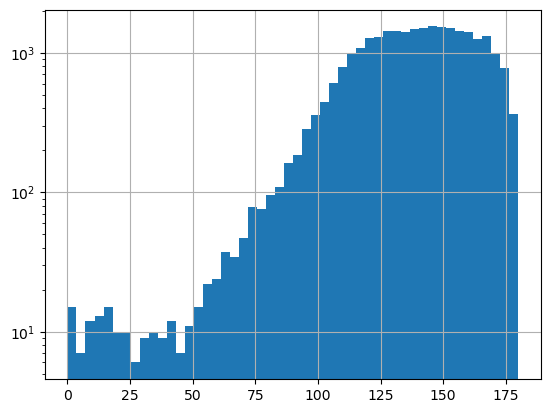

In [ ]:
events_df['fThetaRec'].hist(bins=50, log=True)

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

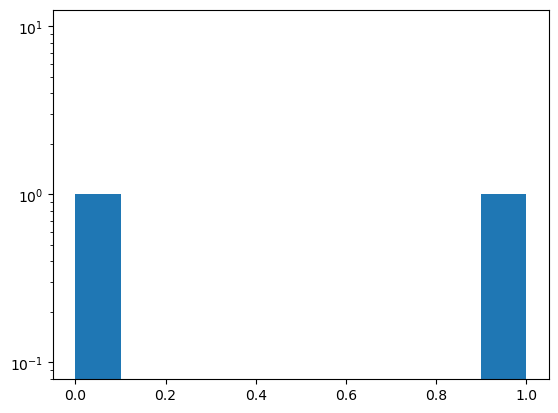

In [ ]:
plt.hist([0,1], log=True)